# Train model

In [50]:
import os
import math
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import hayai_util

portfolio_id = 'model_eu'

context = hayai_util.create_context(portfolio_id)

## Step 1: build the dataset

In [51]:
filename = os.path.join(context['portfolio_dir'], hayai_util.FILE_FEATURES)
df = pd.read_parquet(filename)
# unisci le righe di tutti i dataframe in uno solo
df = df.replace([float('inf'), float('-inf')], float('nan'))
df = df.dropna()
df.shape

(245950, 66)

In [52]:
df.columns

Index(['AUDEUR', 'BZ', 'CNYEUR', 'EURCAD', 'EURCHF', 'EURJPY', 'EURUSD',
       'FTSEMIB.MI', 'GBPEUR', 'GC', 'NZDEUR', '^FCHI', '^N100', '^STOXX50E',
       '^XDE', 'close_range', 'country_Belgium', 'country_Cyprus',
       'country_Denmark', 'country_Finland', 'country_France',
       'country_Germany', 'country_Greece', 'country_Guernsey',
       'country_Ireland', 'country_Italy', 'country_Jersey',
       'country_Luxembourg', 'country_Netherlands', 'country_Norway',
       'country_Spain', 'country_Sweden', 'country_Switzerland',
       'country_United Kingdom', 'date', 'day_of_week', 'hl_range',
       'log_return', 'mom_10', 'mom_20', 'mom_5', 'mom_rank', 'mom_vol_adj',
       'sector_Basic Materials', 'sector_Consumer Discretionary',
       'sector_Consumer Staples', 'sector_Energy', 'sector_Finance',
       'sector_Health Care', 'sector_Industrials', 'sector_Miscellaneous',
       'sector_Real Estate', 'sector_Technology', 'sector_Telecommunications',
       'sector_Utilities'

## EDA

In [53]:
df.describe()

,AUDEUR,BZ,CNYEUR,EURCAD,EURCHF,EURJPY,EURUSD,FTSEMIB.MI,GBPEUR,GC,...,target,time_since_high,trend_50,vol_10,vol_20,vol_ratio,vol_regime,volume_shock,volume_zscore,zscore_20
count,245950.000000,245950.000000,245950.000000,245950.000000,245950.000000,245950.000000,245950.000000,245950.000000,245950.000000,245950.000000,...,245950.000000,245950.000000,245950.000000,245950.000000,245950.000000,245950.000000,245950.000000,245950.000000,245950.000000,245950.000000
mean,0.612691,81.184302,0.130742,1.481041,0.969029,155.958973,1.096431,31955.642167,1.167493,2507.328045,...,-0.029236,377.383257,-0.012470,0.053974,0.063481,0.873614,0.944183,1.015660,0.030002,-0.029556
std,0.033507,12.849808,0.007162,0.083087,0.040292,15.539582,0.050022,7008.765822,0.021142,885.563799,...,1.418401,329.517693,0.141605,0.046251,0.051044,0.273355,0.364323,0.741469,1.039540,1.292495
min,0.542240,58.919998,0.118201,1.289990,0.900120,124.993202,0.959619,20353.000000,1.114430,1623.300049,...,-5.000000,0.000000,-0.480995,0.002718,0.003424,0.245166,0.239283,0.000000,-1.555032,-2.635343
25%,0.596930,72.550003,0.126334,1.440390,0.937400,142.585007,1.065825,26576.000000,1.151600,1862.900024,...,-0.742192,90.000000,-0.078984,0.024975,0.031372,0.672804,0.687071,0.606357,-0.640743,-1.082347
50%,0.609670,79.680000,0.130120,1.472280,0.959930,158.841995,1.088625,30409.000000,1.166530,2032.199951,...,-0.011358,293.000000,-0.005611,0.039997,0.048290,0.888819,0.898632,0.858623,-0.252485,-0.088268
75%,0.633660,86.599998,0.135613,1.513770,0.986740,165.201004,1.135680,37056.000000,1.185080,2914.300049,...,0.702164,606.000000,0.059091,0.065754,0.077010,1.088571,1.150109,1.195467,0.421882,1.032277
max,0.698330,127.980003,0.148069,1.643160,1.093000,186.289993,1.201764,47426.000000,1.214920,5318.399902,...,5.000000,1250.000000,0.460782,0.280100,0.316094,1.378297,2.061857,5.070663,3.720936,2.741262


In [54]:
df = df.drop(columns=['date', 'symbol'])
df.info()

<class 'pandas.DataFrame'>
Index: 245950 entries, 60 to 275596
Data columns (total 64 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   AUDEUR                         245950 non-null  float64
 1   BZ                             245950 non-null  float64
 2   CNYEUR                         245950 non-null  float64
 3   EURCAD                         245950 non-null  float64
 4   EURCHF                         245950 non-null  float64
 5   EURJPY                         245950 non-null  float64
 6   EURUSD                         245950 non-null  float64
 7   FTSEMIB.MI                     245950 non-null  float64
 8   GBPEUR                         245950 non-null  float64
 9   GC                             245950 non-null  float64
 10  NZDEUR                         245950 non-null  float64
 11  ^FCHI                          245950 non-null  float64
 12  ^N100                          245950 non-nul

In [55]:
# raise an error if there are any missing values
if df.isnull().values.any():
    raise ValueError("There are missing values in the dataframe")

In [56]:
df['close_range'].unique()

array([0.46153997, 0.5       , 0.7234027 , ..., 0.42483659, 0.62015469,
       0.06976792], shape=(155034,))

## Target analysis

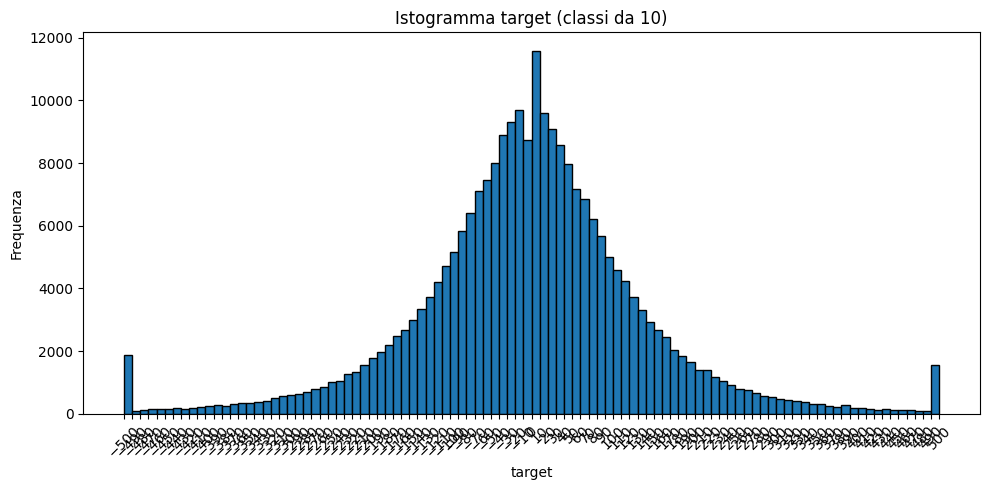

In [57]:
# Istogramma del target con classi (ampiezza) di 50
target_values = df['target']
target_values = target_values * 100
bin_start = math.floor(target_values.min() / 10) * 10
bin_end = math.ceil(target_values.max() / 10) * 10
bins = list(range(int(bin_start), int(bin_end) + 10, 10))

plt.figure(figsize=(10, 5))
plt.hist(target_values, bins=bins, edgecolor='black')
plt.title("Istogramma target (classi da 10)")
plt.xlabel("target")
plt.ylabel("Frequenza")
plt.xticks(bins, rotation=45)
plt.tight_layout()
plt.show()

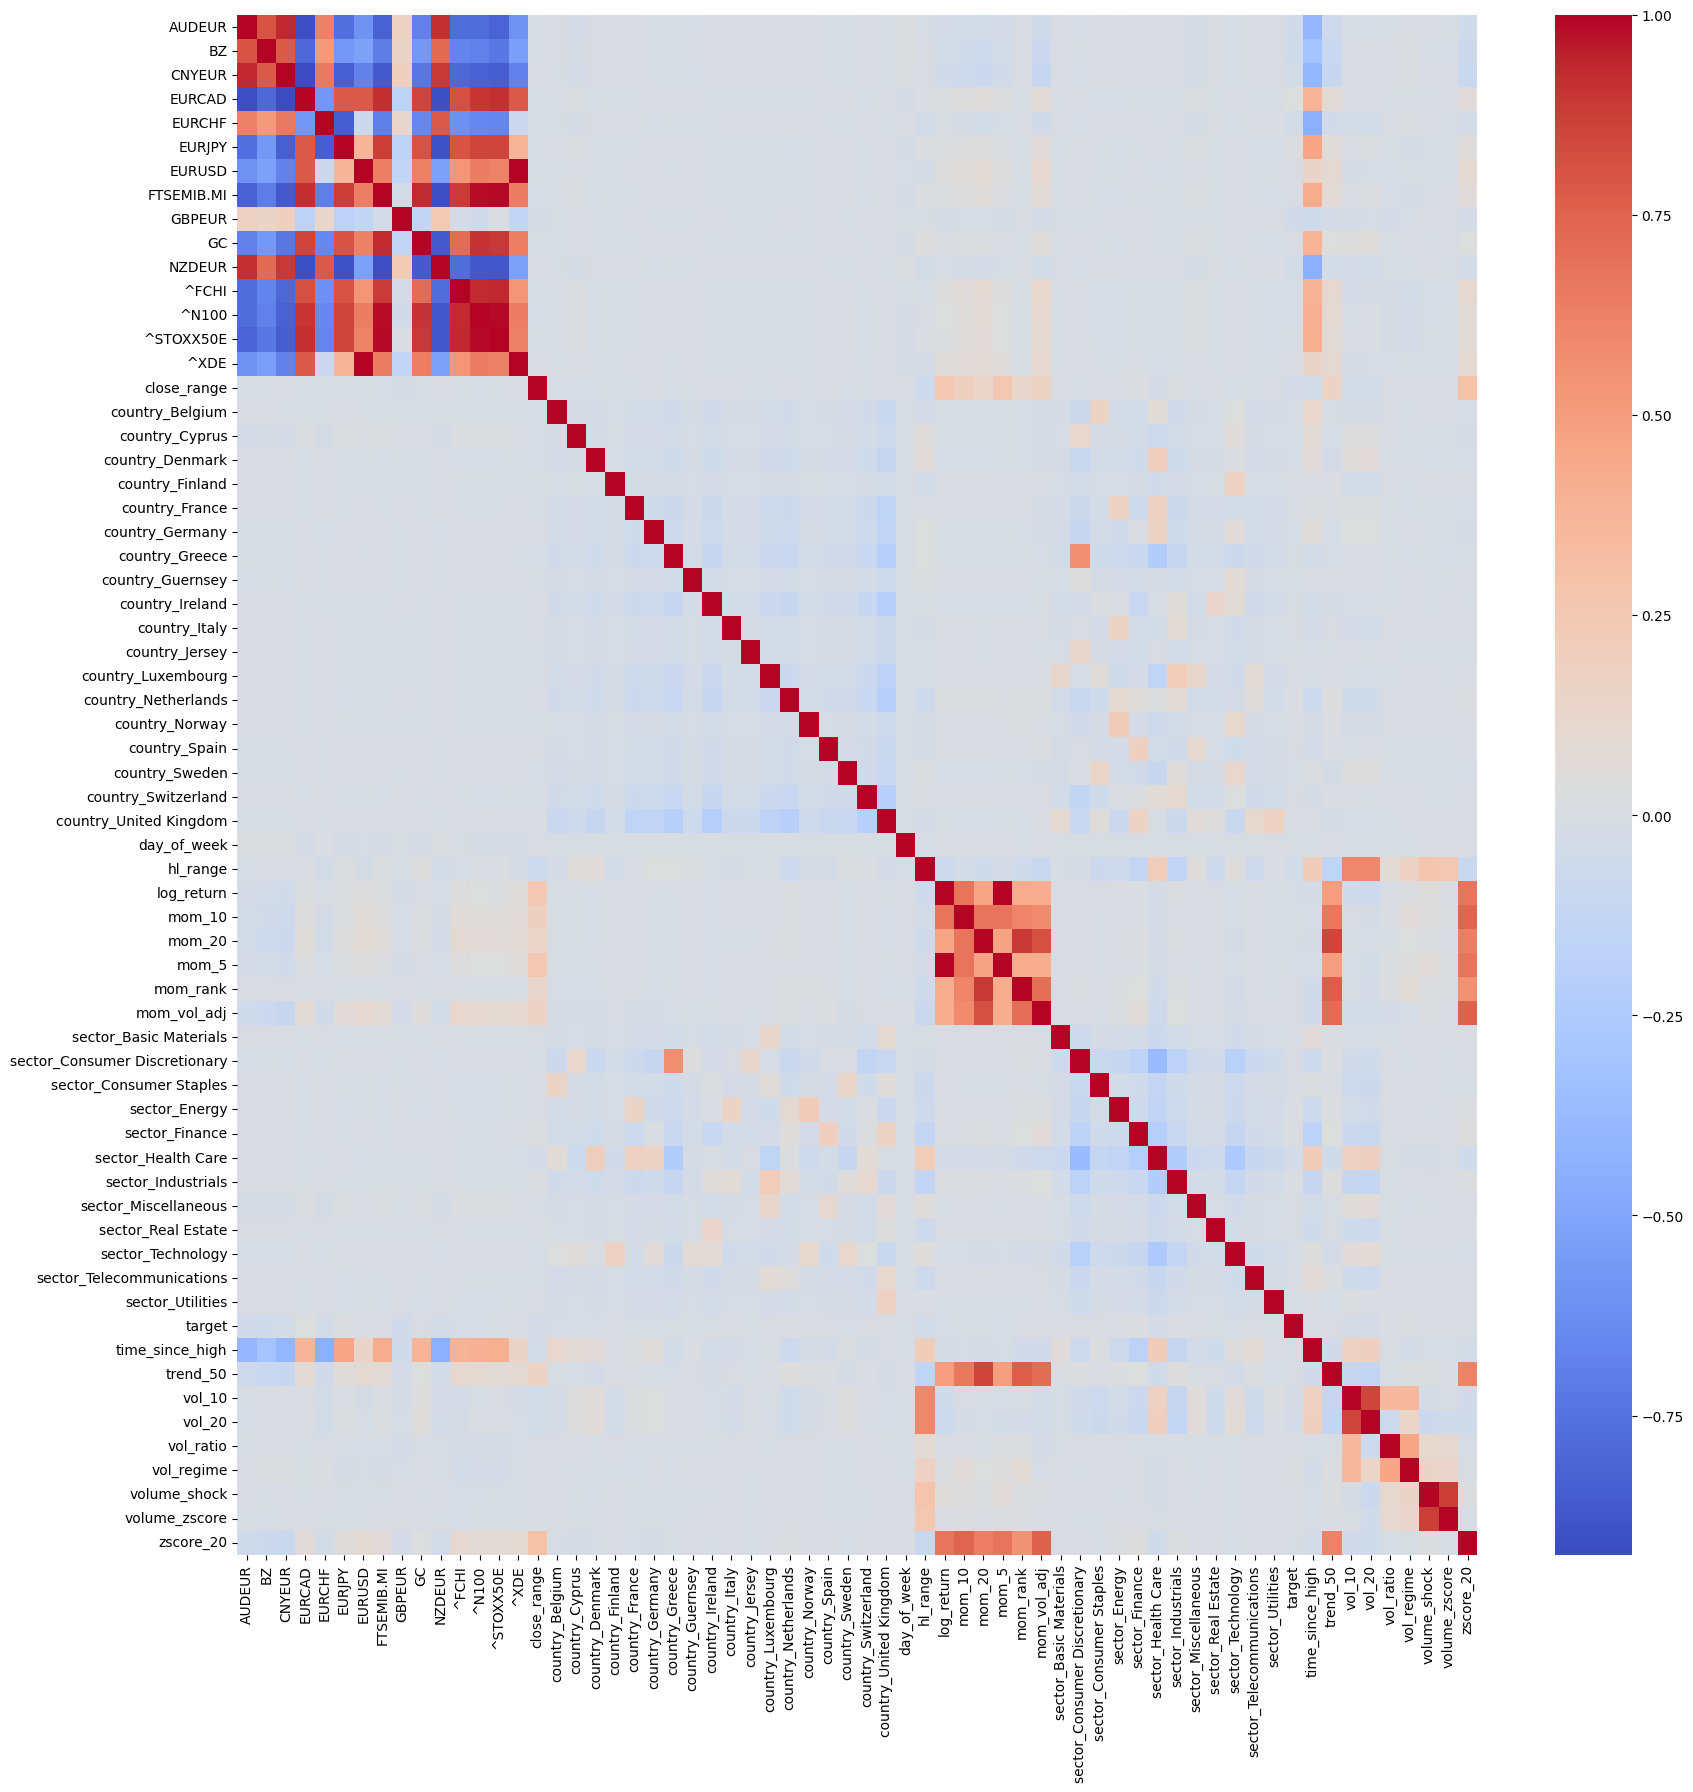

In [58]:
# display the correlation map using seaborn
plt.figure(figsize=(20, 20))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm')
plt.show()

## Normalize

In [59]:
maxs = df.max()
mins = df.min()
df = (df - mins) / (maxs - mins)
label_min = mins['target']
label_max = maxs['target']
hayai_util.save_normalization_params(label_min, label_max)
maxs.index.name = "col"
maxs.name = "value"
maxs.to_csv(os.path.join(context['portfolio_dir'], "maxs.csv"), index=True)
mins.index.name = "col"
mins.name = "value"
mins.to_csv(os.path.join(context['portfolio_dir'], "mins.csv"), index=True)

In [ ]:
# check for +inf or -inf in mins and maxs, thrown an exception if found
if maxs.isin([float('inf'), float('-inf')]).any():
    raise ValueError("There are +inf or -inf values in maxs")
if mins.isin([float('inf'), float('-inf')]).any():
    raise ValueError("There are +inf or -inf values in mins")

## Model building

In [60]:
labels = df['target'].values
df = df.drop(columns=['target'])
data = df.values


In [61]:
from keras.models import Sequential
from keras.layers import Input, Dense,Conv1D,Conv2D,Flatten,MaxPool2D,BatchNormalization,MaxPooling1D
from keras.optimizers import Adam, SGD
from sklearn.model_selection import train_test_split
print("Labels Shape: %s" % (labels.shape,))
print("Data Shape: %s" % (data.shape,))
X, X_test, Y, Y_test = train_test_split(data, labels, test_size=0.2, random_state=1,shuffle=True)
print("Train Data Shape: %s" % (X.shape,))
print("Train Labels Shape: %s" % (Y.shape,))
print("Test Data Shape: %s" % (X_test.shape,))
print("Test Labels Shape: %s" % (Y_test.shape,))

Labels Shape: (245950,)
Data Shape: (245950, 63)
Train Data Shape: (196760, 63)
Train Labels Shape: (196760,)
Test Data Shape: (49190, 63)
Test Labels Shape: (49190,)


In [62]:
n_row = data.shape[1]
channels = 1 # non ci sono colori, il channel è 1 (usato solo in Conv2D)
batch_size = 64

model = Sequential()
model.add(Input(shape=(n_row,), name='input_layer'))
model.add(Dense(100, activation='relu',name='layerDense1'))
model.add(Dense(80, activation='relu',name='layerDense2'))
model.add(Dense(20, activation='relu',name='layerDense3'))
model.add(Dense(1,activation='sigmoid',name='output_layer'))
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ layerDense1 (Dense)             │ (None, 100)            │         6,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layerDense2 (Dense)             │ (None, 80)             │         8,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layerDense3 (Dense)             │ (None, 20)             │         1,620 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,121 (62.97 KB)

 Trainable params: 16,121 (62.97 KB)

 Non-trainable params: 0 (0.00 B)

In [63]:
# questa è la funzione di costo
optimizer = Adam(learning_rate=context['learning_rate'])
model.compile(loss='mean_squared_error', optimizer=optimizer)
#model.compile(loss='mean_squared_error', optimizer='SGD')

# questo è il training
model.fit(
    X,
    Y,
    epochs=context['epochs'],
    shuffle=True,
    verbose=2,
    batch_size=context['batch_size'],
    validation_split=context['validation_split']
)
# il modello è pronto, applichiamo il modello al dataset di test

results = model.evaluate(X_test, Y_test, verbose=2,)
print("Test loss: %f" % results)
filename = os.path.join(context['portfolio_dir'], 'model_summary.txt')
with open(filename, 'w',encoding='utf-8') as f:
    model.summary(print_fn=lambda x: f.write(x + '\n'))
model.save(os.path.join(context['portfolio_dir'], 'model.keras'))
print("Model saved to: %s" % os.path.join(context['portfolio_dir'], 'model.keras'))

Epoch 1/20
2460/2460 - 3s - 1ms/step - loss: 0.0200 - val_loss: 0.0200
Epoch 2/20
2460/2460 - 3s - 1ms/step - loss: 0.0197 - val_loss: 0.0197
Epoch 3/20
2460/2460 - 3s - 1ms/step - loss: 0.0195 - val_loss: 0.0196
Epoch 4/20
2460/2460 - 2s - 976us/step - loss: 0.0192 - val_loss: 0.0193
Epoch 5/20
2460/2460 - 2s - 1ms/step - loss: 0.0189 - val_loss: 0.0191
Epoch 6/20
2460/2460 - 2s - 998us/step - loss: 0.0187 - val_loss: 0.0190
Epoch 7/20
2460/2460 - 2s - 991us/step - loss: 0.0184 - val_loss: 0.0190
Epoch 8/20
2460/2460 - 3s - 1ms/step - loss: 0.0182 - val_loss: 0.0187
Epoch 9/20
2460/2460 - 3s - 1ms/step - loss: 0.0180 - val_loss: 0.0185
Epoch 10/20
2460/2460 - 3s - 1ms/step - loss: 0.0178 - val_loss: 0.0184
Epoch 11/20
2460/2460 - 3s - 1ms/step - loss: 0.0177 - val_loss: 0.0185
Epoch 12/20
2460/2460 - 3s - 1ms/step - loss: 0.0175 - val_loss: 0.0183
Epoch 13/20
2460/2460 - 4s - 1ms/step - loss: 0.0173 - val_loss: 0.0181
Epoch 14/20
2460/2460 - 4s - 2ms/step - loss: 0.0172 - val_loss: 0.

Model saved to: data\model_eu\model.keras


In [64]:
tp = 0
tn = 0
fp = 0
fn = 0
#denormalize labels
labels = Y_test * (label_max - label_min) + label_min
predictions = model.predict(X_test, verbose=0)
print("min and max of predictions ", predictions.min(), predictions.max())
errors = []
for i in range(len(X_test)):
    p = predictions[i][0]
    label = labels[i]
    p = p * (label_max - label_min) + label_min # denormalize prediction
    if i < 30:
        print(f"Label: {label:.4f}, Prediction: {p:.4f}")
    errors.append((label - p))
    if label > 0 and p > 0:
        tp += 1
    elif label <= 0 and p <= 0:
        tn += 1
    elif label <= 0 and p > 0:
        fp += 1
    elif label > 0 and p <= 0:
        fn += 1
eqm = math.sqrt(sum([e**2 for e in errors])/len(errors))
print(f"Mean Squared Error: {eqm:.4f}")
print("True Positives: %d, True Negatives: %d, False Positives: %d, False Negatives: %d" % (tp, tn, fp, fn))
print("positive labels: %d, negative labels: %d" % (sum(labels > 0), sum(labels <= 0)))
print("Sum true",tp+tn, "Sum false",fp+fn)
print("Precision: %.4f" % (tp / (tp + fp) if (tp + fp) > 0 else 0))
print("Recall: %.4f" % (tp / (tp + fn) if (tp + fn) > 0 else 0))
print("Accuracy: %.4f" % ((tp + tn) / len(X_test) if len(X_test) > 0 else 0))

pred_denorm = predictions.flatten() * (label_max - label_min) + label_min
corr = pd.Series(labels).corr(pd.Series(pred_denorm))
print(f"Correlation (labels vs predictions): {corr:.4f}")

min and max of predictions  0.11074674 0.8481197
Label: -2.3530, Prediction: -1.9444
Label: 0.4653, Prediction: 0.7301
Label: 2.2941, Prediction: -0.4114
Label: -0.6118, Prediction: -0.3763
Label: -0.5201, Prediction: -0.2162
Label: 0.5366, Prediction: -0.0378
Label: 0.2633, Prediction: 0.2488
Label: -0.0726, Prediction: -0.0889
Label: -1.5911, Prediction: -0.0669
Label: 0.3175, Prediction: -0.1068
Label: 1.7296, Prediction: 0.4290
Label: 0.4680, Prediction: 0.4621
Label: -2.0154, Prediction: -2.6302
Label: -2.7798, Prediction: 0.0146
Label: 0.3010, Prediction: -0.8695
Label: 0.0836, Prediction: -0.4313
Label: -0.1336, Prediction: -0.2419
Label: 0.5218, Prediction: -0.4970
Label: -0.2753, Prediction: -0.0744
Label: -4.5148, Prediction: -2.0292
Label: 0.0578, Prediction: 0.1751
Label: 1.3274, Prediction: -0.0347
Label: 0.1895, Prediction: 0.3069
Label: 5.0000, Prediction: -0.3096
Label: -0.6574, Prediction: 0.8606
Label: -0.4308, Prediction: -0.0889
Label: 1.4665, Prediction: 0.7231
Lab